In [3]:
import pandas as pd
import mysql.connector

# Criando a conexão com o banco que você fez no Workbench
try:
    conexao = mysql.connector.connect(
        host='localhost',
        user='root',
        password='', # <-- Coloque sua senha do MySQL aqui
        database='projeto_financas'
    )
    print("Conexão realizada com sucesso!")

    # Puxando os dados da VIEW que criamos juntos no SQL
    query = "SELECT * FROM vw_resumo_financeiro"
    df = pd.read_sql(query, conexao)

    # Fechando a conexão (boa prática)
    conexao.close()

    # Mostrando os primeiros dados na tela
    print("\nDados carregados do MySQL:")
    display(df)

except Exception as e:
    print(f"Erro ao conectar: {e}")

Conexão realizada com sucesso!

Dados carregados do MySQL:


C:\Users\julii\AppData\Local\Temp\ipykernel_1628\1371346444.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexao)


,nome_cliente,renda_mensal,score_credito,total_pago,total_em_atraso
0,Carlos Silva,5500.0,850,2000.0,0.0
1,Mariana Souza,3200.0,450,1000.0,1000.0
2,Juliana Paes,2100.0,300,0.0,1000.0


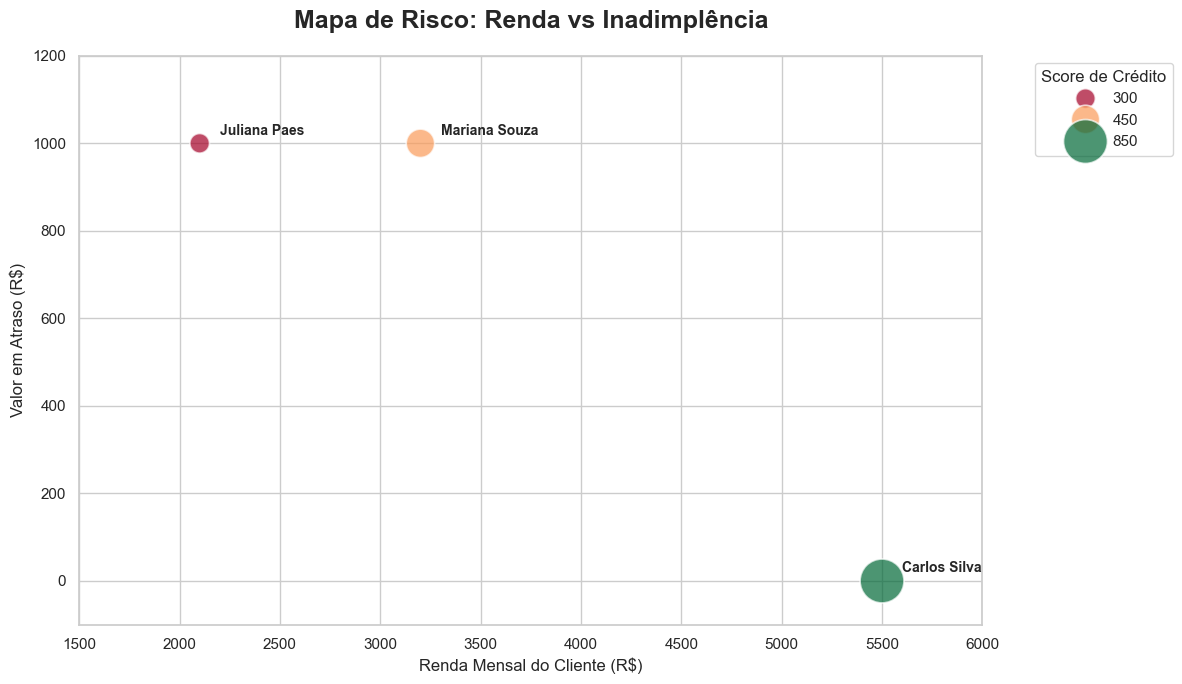

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mudando o "clima" do gráfico (Estilo Dark ou White)
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 7))

# 2. Criando o gráfico com cores mais vibrantes e transparência
grafico = sns.scatterplot(
    data=df, 
    x='renda_mensal', 
    y='total_em_atraso', 
    size='score_credito', 
    hue='score_credito', # Agora a cor muda de acordo com o score (quente/frio)
    sizes=(200, 1000),   # Bolinhas maiores para facilitar a leitura
    alpha=0.7,           # Transparência para dar um ar moderno
    palette='RdYlGn'     # Vermelho (Ruim) para Verde (Bom)
)

# 3. Colocando Rótulos (Labels) nos pontos
# Isso faz com que o nome do cliente apareça do lado da bolinha
for i in range(df.shape[0]):
    plt.text(
        x=df.renda_mensal[i]+100, 
        y=df.total_em_atraso[i]+20, 
        s=df.nome_cliente[i], 
        fontweight='bold', 
        size=10
    )

# 4. Títulos e Legendas mais profissionais
plt.title('Mapa de Risco: Renda vs Inadimplência', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Renda Mensal do Cliente (R$)', fontsize=12)
plt.ylabel('Valor em Atraso (R$)', fontsize=12)
plt.legend(title='Score de Crédito', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustando os limites para as bolinhas não cortarem na borda
plt.xlim(1500, 6000)
plt.ylim(-100, 1200)

plt.tight_layout()
plt.show()

C:\Users\julii\AppData\Local\Temp\ipykernel_27908\3675190989.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_agrupado, x='faixa_score', y='total_em_atraso', palette='Reds_r')


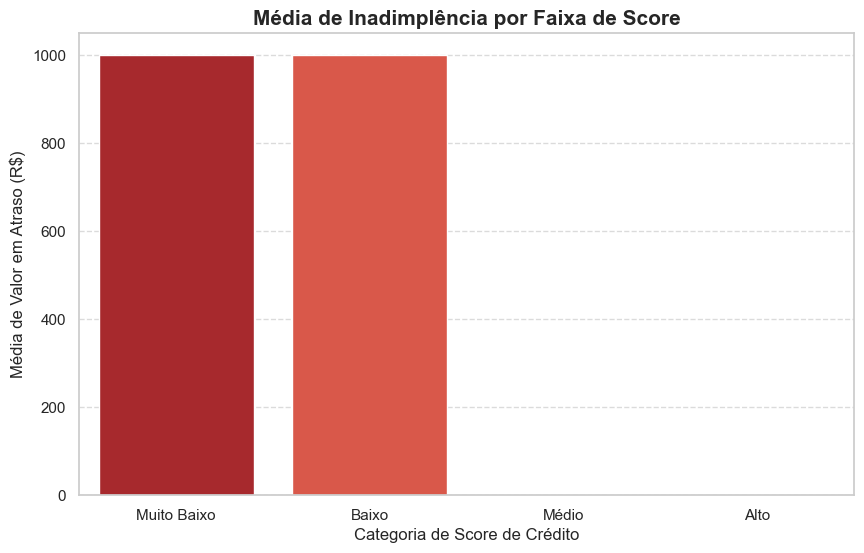

In [9]:
# 1. Criando as Faixas de Score (Buckets)
# Isso agrupa milhares de clientes em apenas 4 categorias
bins = [0, 300, 600, 800, 1000]
labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto']
df['faixa_score'] = pd.cut(df['score_credito'], bins=bins, labels=labels)

# 2. Agrupando os dados para o gráfico
df_agrupado = df.groupby('faixa_score', observed=True)['total_em_atraso'].mean().reset_index()

# 3. Criando o Gráfico de Barras (Ideal para muitos dados)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_agrupado, x='faixa_score', y='total_em_atraso', palette='Reds_r')

plt.title('Média de Inadimplência por Faixa de Score', fontsize=15, fontweight='bold')
plt.xlabel('Categoria de Score de Crédito', fontsize=12)
plt.ylabel('Média de Valor em Atraso (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [10]:
# Exportando os dados para a pasta 'data'
df.to_csv('../data/dados_para_bi.csv', index=False, sep=';', encoding='latin1')
print("Arquivo exportado com sucesso! Agora temos o combustível para o Power BI.")

Arquivo exportado com sucesso! Agora temos o combustível para o Power BI.


In [6]:
import mysql.connector
import pandas as pd

try:
    conexao = mysql.connector.connect(
        host='localhost',
        user='root',
        password='', 
        database='projeto_financas'
    )

    # Query completa com Cidade
    query = """
    SELECT 
        c.nome_cliente, 
        c.cidade, 
        c.renda_mensal, 
        c.score_credito, 
        SUM(CASE WHEN p.status_pagamento = 'Pago' THEN p.valor_parcela ELSE 0 END) AS total_pago,
        SUM(CASE WHEN p.status_pagamento = 'Atrasado' THEN p.valor_parcela ELSE 0 END) AS total_em_atraso
    FROM Clientes c
    INNER JOIN Contratos ct ON c.id_cliente = ct.id_cliente
    INNER JOIN Pagamentos p ON ct.id_contrato = p.id_contrato
    GROUP BY c.id_cliente, c.nome_cliente, c.cidade, c.renda_mensal, c.score_credito;
    """

    df_completo = pd.read_sql(query, conexao)
    conexao.close()

    # Criando a 'faixa_score' novamente para o Power BI não dar erro
    bins = [0, 300, 600, 800, 1000]
    labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto']
    df_completo['faixa_score'] = pd.cut(df_completo['score_credito'], bins=bins, labels=labels)

    # Exportando o arquivo final
    df_completo.to_csv('../data/dados_para_bi.csv', index=False, sep=';', encoding='latin1')
    print("Sucesso! Arquivo atualizado com Cidade e Faixa de Score.")

except Exception as e:
    print(f"Erro: {e}")

Sucesso! Arquivo atualizado com Cidade e Faixa de Score.


C:\Users\julii\AppData\Local\Temp\ipykernel_1628\1442212288.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_completo = pd.read_sql(query, conexao)


In [11]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Conexão (Ajuste a senha se necessário)
engine = create_engine('mysql+mysqlconnector://root:@localhost/projeto_financas')

# 2. Query com a NOVA ESCALA
# Limpei os espaços invisíveis que causam erro de sintaxe
query = """
SELECT 
    nome_cliente,
    score_credito,
    total_em_atraso,
    CASE 
        WHEN score_credito > 700 THEN 'Excelente'
        WHEN score_credito BETWEEN 501 AND 700 THEN 'Alto'
        WHEN score_credito BETWEEN 301 AND 500 THEN 'Médio'
        ELSE 'Crítico'
    END AS faixa_score
FROM vw_resumo_financeiro;
"""

# 3. Carregar os dados
df = pd.read_sql(query, engine)

# 4. Salvar o CSV final (Ajustado para Excel Brasil e acentos perfeitos)
df.to_csv('D:/testemysql/projetofinancas/dados_credito_final.csv', 
          index=False, 
          sep=';', 
          encoding='utf-8-sig')

print("Agora sim! Arquivo atualizado com a nova escala e acentos corrigidos.")
df

Agora sim! Arquivo atualizado com a nova escala e acentos corrigidos.


,nome_cliente,score_credito,total_em_atraso,faixa_score
0,Carlos Silva,850,0.0,Excelente
1,Mariana Souza,450,1000.0,Médio
2,Juliana Paes,300,1000.0,Crítico
3,Ricardo Alves,600,1000.0,Alto
